# Problem Statement

In [ ]:
Develop a Machine Learning-based web application that predicts employee salaries based on factors such as
experience, age, education level, and city. The goal of the project is to help estimate salaries accurately using
historical employee data and regression algorithms.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("job_salary_prediction_dataset.csv")

In [3]:
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


In [4]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [5]:
df.shape

(250000, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [7]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [8]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

# Data Cleaning

In [10]:
# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [11]:
print(df.isnull().sum())

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64


In [12]:
df.drop_duplicates(inplace=True)

# Outlier Removal

In [15]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Outliers Removed")

print(df.shape)

Outliers Removed
(247399, 10)


# Visualize Outliers

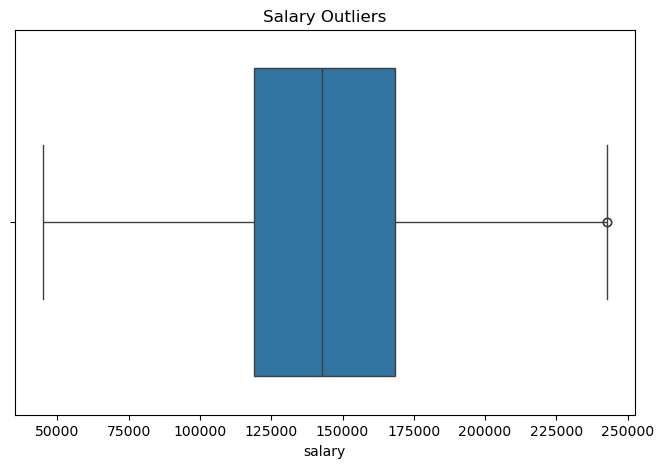

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["salary"])
plt.title("Salary Outliers")
plt.show()

# Histogram

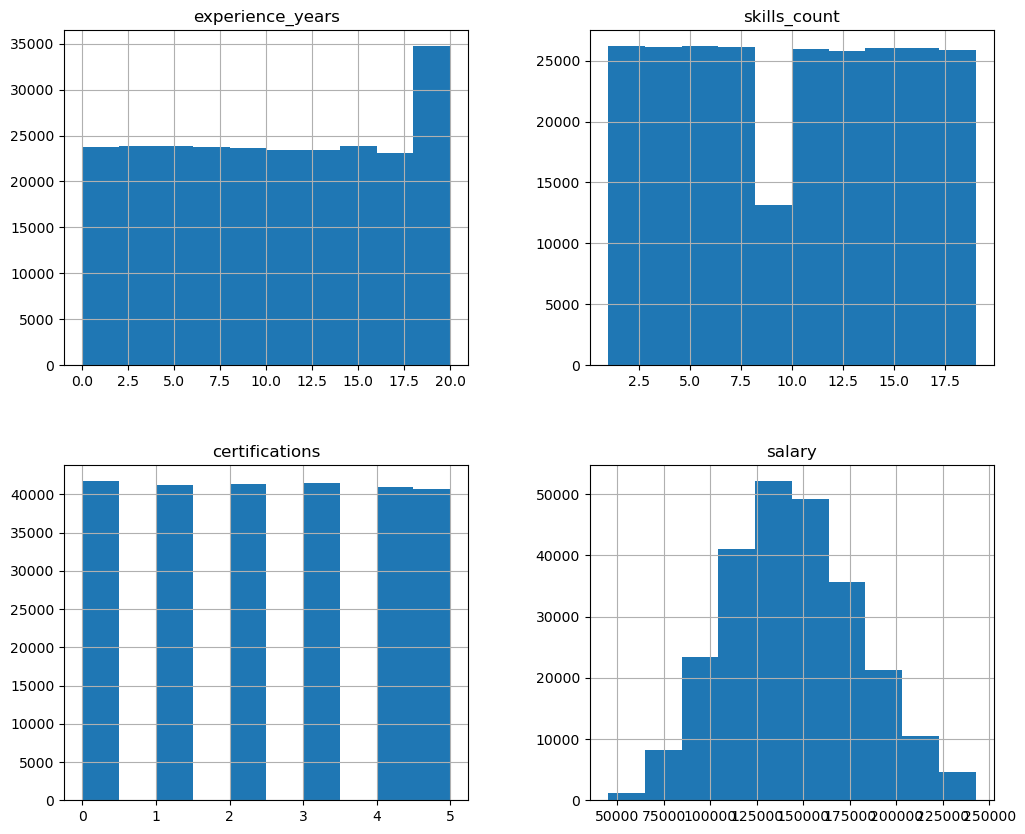

In [17]:
df.hist(figsize=(12,10))
plt.show()

# Boxplot

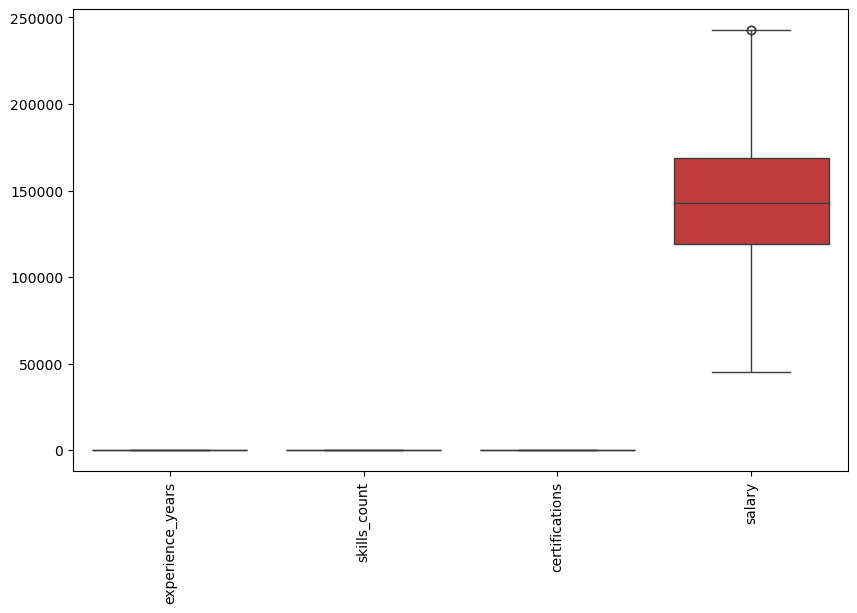

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

# Correlation Heatmap

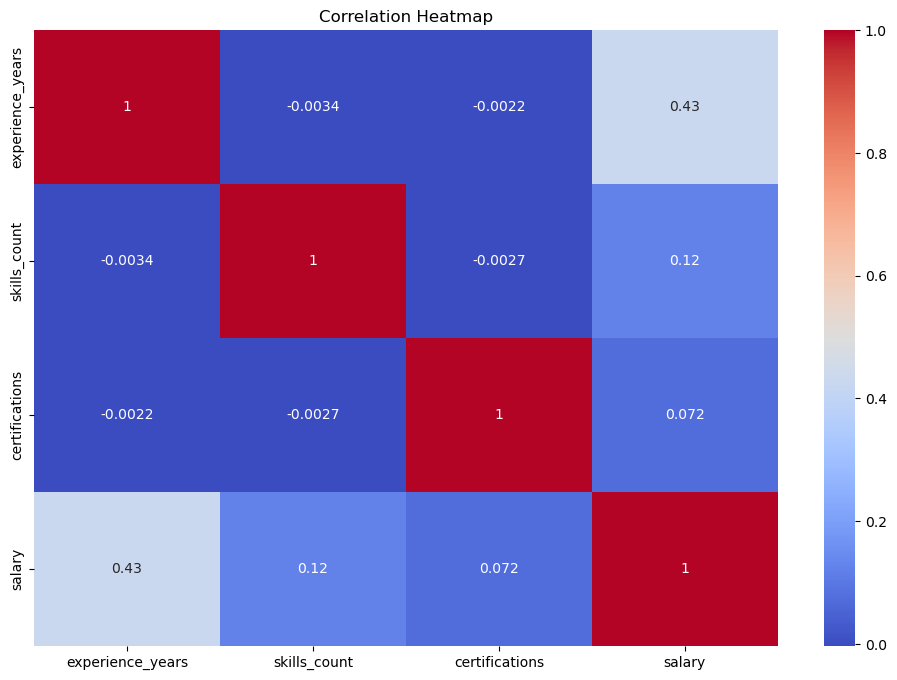

In [19]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# Encode Categorical Columns

In [21]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Target Variable 

In [22]:
# Target Variable 
y = df["salary"]

# Features
X = df.drop("salary", axis=1)

# Convert Categorical--> Numeric

In [23]:
X = pd.get_dummies(X, drop_first=True)

In [24]:
# Convert everything to numeric
X = X.apply(pd.to_numeric, errors='coerce')

# Replace NaN and infinite values
X.fillna(0, inplace=True)
X.replace([np.inf, -np.inf], 0, inplace=True)

y = pd.to_numeric(y, errors='coerce').fillna(0)

In [15]:
import joblib
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, "features.pkl")

['features.pkl']

# Train-Test Split

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (197919, 9)
Test: (49480, 9)


# Model Training

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [29]:
y_pred = model.predict(X_test)

In [30]:
y_pred

array([121972.25887188, 175869.60135175, 150382.02845066, ...,
       121204.56908858, 159811.9834194 , 170964.19678568])

# Evalution 

In [31]:
from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2 Score:", r2)
print("MSE:", mse)

R2 Score: 0.43808895410108983
MSE: 718848710.1738579


In [33]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF R2:", r2_score(y_test, y_pred_rf))

RF R2: 0.9666507375902288


# Bagging Model

In [34]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

In [39]:
# Base model
base_model = DecisionTreeRegressor()

# Bagging
bagging = BaggingRegressor(
    estimator=base_model,
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

bagging.fit(X_train, y_train)

y_pred_bag = bagging.predict(X_test)
print("Bagging R2:", r2_score(y_test, y_pred_bag))

Bagging R2: 0.9659708650631534


# Boosting Model

In [38]:
from sklearn.ensemble import GradientBoostingRegressor

boost = GradientBoostingRegressor(
     n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

boost.fit(X_train, y_train)

y_pred_boost = boost.predict(X_test)

print("Boosting R2:", r2_score(y_test, y_pred_boost))

Boosting R2: 0.9348474447590841


# XG Boost

In [40]:
!pip install xgboost

In [41]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost R2:", r2_score(y_test, y_pred_xgb))

XGBoost R2: 0.9747452139854431


# Comparing All Models

In [42]:
print("Linear Regression:", r2)
print("Random Forest:", r2_score(y_test, y_pred_rf))
print("Bagging:", r2_score(y_test, y_pred_bag))
print("Boosting:", r2_score(y_test, y_pred_boost))

Linear Regression: 0.43808895410108983
Random Forest: 0.9666507375902288
Bagging: 0.9659708650631534
Boosting: 0.9348474447590841


In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mae)
print("RMSE:", rmse)

R2: 0.43808895410108983
MAE: 21279.831127922636
RMSE: 26811.35412794098


# Visualization

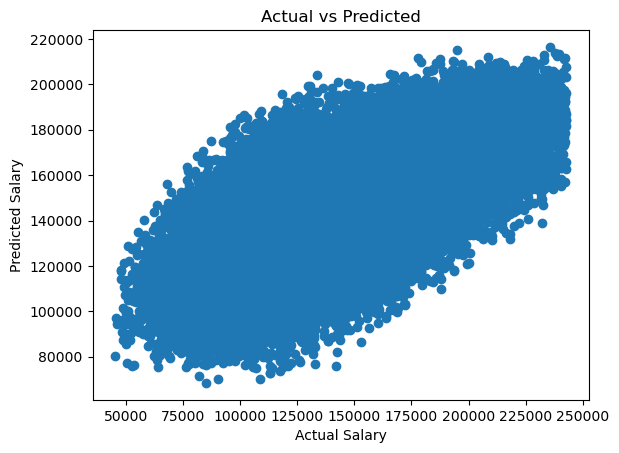

In [44]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

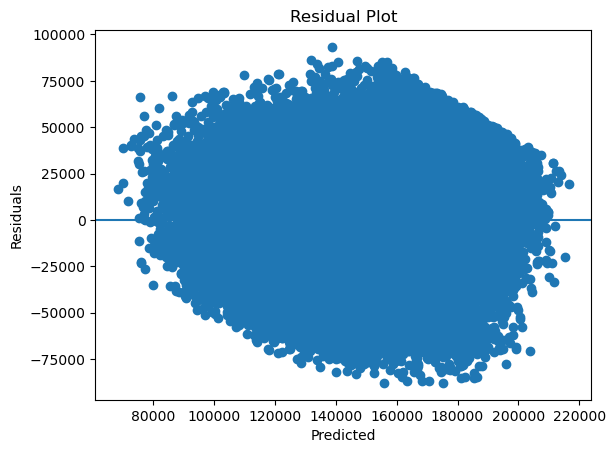

In [45]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [46]:
import pandas as pd

importance = rf.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(10))

            Feature  Importance
6          location    0.331473
1  experience_years    0.194923
0         job_title    0.166422
5      company_size    0.157648
2   education_level    0.098484
3      skills_count    0.027165
8    certifications    0.010349
4          industry    0.007483
7       remote_work    0.006053


In [33]:
import joblib
joblib.dump(model, "salary_model.pkl")

['salary_model.pkl']